# NUDGE — Norman 2019: is a CRISPRa combo *additive*, or *synergistic / buffering*?

**The question a linear screen can't answer.** Combine two perturbations A and B. Is
A+B just **more of the same knob** (additive) — or does the pair deviate from the
additive prediction: **super-additive** (synergistic) or **sub-additive**
(buffering / epistatic)? Thousands of combination-therapy and genetic-interaction
labs ask exactly this. A per-gene differential test never models *how two effects
compose*, so it structurally cannot make this call.

**How NUDGE reads it.** A, B and A+B are three **operating points** against a shared
control. NUDGE reduces each to a scalar **effect** (a response-magnitude shift vs
control, in **log-fold-change space**), so the additive null
`effect(A+B) = effect(A) + effect(B)` is **Bliss independence**. The **interaction**
`effect(A+B) − [effect(A)+effect(B)]` is carried with a **bootstrap CI over cells**,
and a fail-safe classifier calls `additive` / `synergistic` / `buffering` — or
**abstains** (`no-effect` / `unresolved`) when an arm is underpowered or the CI is
too wide. It never forces a call.

**Data:** Norman *et al.* 2019 (GSE133344) — CRISPRa single + two-gene perturbations
in K562, ~111k cells, raw counts. We validate against the paper's own genetic-
interaction taxonomy.

In [1]:
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

from nudge.inference.bridge import combo_effect_scores
from nudge.inference.epistasis import attribute_synergy

NORMAN = '/media/nick/Seagate Hub/norman_2019/norman_2019.h5ad'
assert os.path.exists(NORMAN), (
    'Norman 2019 h5ad not found — download it to '
    f'{NORMAN!r} (see tests/inference/test_epistasis.py).'
)
adata = ad.read_h5ad(NORMAN)
# Norman labels conditions in obs['perturbation_name']: 'control', singles like
# 'CBL', doubles like 'CBL+CNN1'.
adata.obs['condition'] = adata.obs['perturbation_name'].astype(str).values
print('cells x genes:', adata.shape)
vc = adata.obs['condition'].value_counts()
print('control cells:', int(vc.get('control', 0)))

cells x genes: (111255, 19018)
control cells: 11835


## A panel of pairs across the interaction classes

We pick five pairs spanning the interaction classes and let NUDGE call each — no
cherry-picking. An **independent literature fact-check** (summarised at the end) grades how
well each call is *grounded* in Norman 2019: **two pairs are explicitly characterised** by
the paper, **two** are consistent with its erythroid clusters but carry no per-pair label,
and **one** is a paralog control the paper does not analyse. The per-cell **effect score**
projects each cell onto the **additive axis fixed by the two single arms** (computed from the
singles only, never the combo), so a positive interaction is unambiguously super-additive
*along the axis the singles push*.

In [2]:
PAIRS = {
    'CBL+CNN1':     ('CBL', 'CNN1'),      # Norman Fig 3: emergent erythroid synergy (EXPLICIT)
    'CBL+UBASH3B':  ('CBL', 'UBASH3B'),   # erythroid RTK cluster (Fig 2B); no explicit per-pair label
    'CNN1+UBASH3B': ('CNN1', 'UBASH3B'),  # same erythroid synergy cluster
    'DUSP9+ETS2':   ('DUSP9', 'ETS2'),    # Norman Fig 5: DUSP9-dominant suppression of ETS2 (EXPLICIT)
    'FOXA1+FOXA3':  ('FOXA1', 'FOXA3'),   # paralogs — additive / neutral
}

# return_geometry=True also hands back the off-axis (possible-neomorphic) diagnostic:
# the part of the combo's interaction residual r = v_AB - v_A - v_B that is ORTHOGONAL
# to the additive axis — the emergent component this scalar structurally cannot see
# (NUDGE-LIM-009). attribute_synergy attaches it to the fit and, for a non-additive
# call with off-axis >= on-axis, appends an honest UNDER-count warning to the reason.
results, geoms = {}, {}
for label, (ga, gb) in PAIRS.items():
    ctrl, a, b, ab, geom = combo_effect_scores(
        adata, control_label='control', a_label=ga, b_label=gb,
        ab_label=f'{ga}+{gb}', condition_col='condition', return_geometry=True,
    )
    geoms[label] = geom
    results[label] = attribute_synergy(
        ctrl, a, b, ab, n_boot=500, seed=0, geometry=geom
    )

print(f'{"pair":14} {"call":12} {"interaction":>11} {"95% CI":>18} {"dBIC":>5}  '
      f'{"off-axis":>8} {"ratio":>6}  flag')
for label, r in results.items():
    f = r.fit
    lo, hi = f.ci_interaction
    flag = 'possible neomorphic' if 'neomorphic' in r.reason else ''
    print(f'{label:14} {r.call:12} {f.interaction:+11.3f} '
          f'[{lo:+.3f}, {hi:+.3f}] {f.bic_additive - f.bic_free:+5.0f}  '
          f'{f.off_axis_residual:8.3f} {f.neomorphic_ratio:6.2f}  {flag}')

pair           call         interaction             95% CI  dBIC  off-axis  ratio  flag
CBL+CNN1       synergistic       +0.949 [+0.480, +1.423]   +19     2.535   2.67  possible neomorphic
CBL+UBASH3B    synergistic       +1.089 [+0.751, +1.445]   +44     2.153   1.98  possible neomorphic
CNN1+UBASH3B   synergistic       +1.252 [+0.941, +1.584]   +67     2.209   1.76  possible neomorphic
DUSP9+ETS2     buffering         -2.140 [-2.636, -1.598]  +156     1.329   0.62  
FOXA1+FOXA3    additive          -0.611 [-1.367, +0.249]    -2     1.951   3.19  


## The additive null, drawn

**Left:** observed `effect(A+B)` vs the additive prediction `effect(A)+effect(B)`.
The diagonal *is* the additive null. Points **above** the line are super-additive
(synergistic); **below**, sub-additive (buffering); **on** it, additive.
**Right:** the interaction with its 95% bootstrap CI — a forest plot against 0.
A call is made only when the CI clears 0 *and* a free A+B level beats the additive
null on BIC.

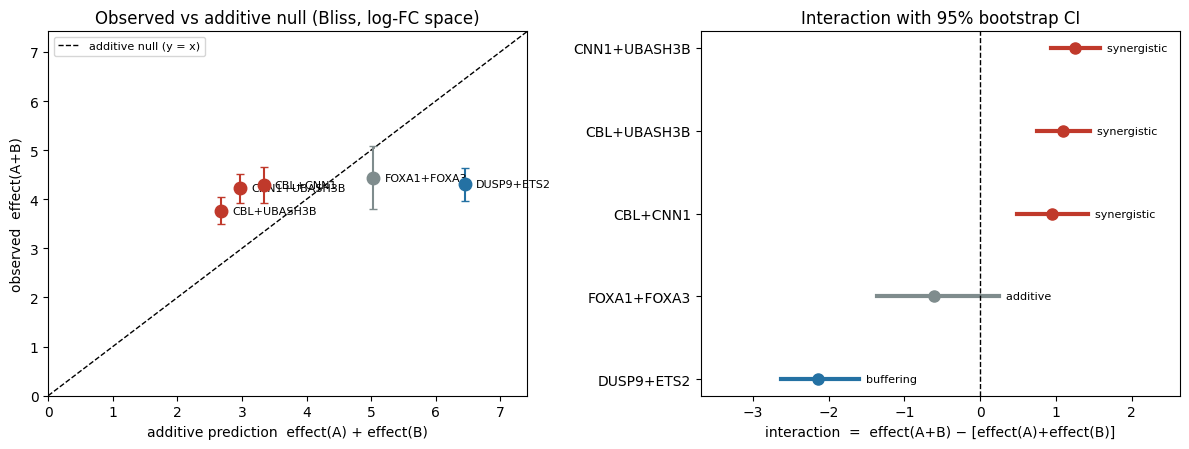

In [3]:
COLORS = {
    'synergistic': '#c0392b', 'buffering': '#2471a3',
    'additive': '#7f8c8d', 'no-effect': '#95a5a6', 'unresolved': '#f39c12',
}
labels = list(results)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: observed vs additive-predicted effect(A+B).
preds = np.array([results[l].fit.additive_pred for l in labels])
obs = np.array([results[l].fit.effect_ab for l in labels])
cis = np.array([results[l].fit.ci_ab for l in labels])
yerr = np.abs(cis.T - obs)
lim = [0, max(preds.max(), obs.max()) * 1.15]
axL.plot(lim, lim, '--', color='k', lw=1, zorder=0, label='additive null (y = x)')
for i, l in enumerate(labels):
    axL.errorbar(preds[i], obs[i], yerr=yerr[:, i:i+1], fmt='o', ms=9,
                 color=COLORS[results[l].call], capsize=3, zorder=3)
    axL.annotate(l, (preds[i], obs[i]), textcoords='offset points',
                 xytext=(8, -2), fontsize=8)
axL.set_xlabel('additive prediction  effect(A) + effect(B)')
axL.set_ylabel('observed  effect(A+B)')
axL.set_title('Observed vs additive null (Bliss, log-FC space)')
axL.set_xlim(lim); axL.set_ylim(lim); axL.legend(loc='upper left', fontsize=8)

# Right: interaction forest plot.
order = sorted(range(len(labels)), key=lambda i: results[labels[i]].fit.interaction)
for row, i in enumerate(order):
    l = labels[i]; f = results[l].fit; lo, hi = f.ci_interaction
    axR.plot([lo, hi], [row, row], color=COLORS[results[l].call], lw=3)
    axR.plot(f.interaction, row, 'o', ms=8, color=COLORS[results[l].call])
    axR.annotate(f'  {results[l].call}', (hi, row), fontsize=8, va='center')
axR.axvline(0, color='k', ls='--', lw=1)
axR.set_yticks(range(len(order)))
axR.set_yticklabels([labels[i] for i in order])
axR.set_xlabel('interaction  =  effect(A+B) − [effect(A)+effect(B)]')
axR.set_title('Interaction with 95% bootstrap CI')
axR.margins(x=0.25)
fig.tight_layout(); plt.show()

## The off-axis blind spot, quantified — *possible neomorphic* structure

NUDGE's scalar interaction is **exactly the on-axis projection** of the combo's full
interaction-residual vector `r = v_AB − v_A − v_B` onto the additive axis
`u = (v_A+v_B)/‖v_A+v_B‖` (fixed by the singles only, never the combo). The component of
`r` **orthogonal** to `u` — the **off-axis residual** — is the emergent piece the scalar
structurally cannot see. In Norman 2019's terms this is the **neomorphic** dimension.

A forensic audit (`design/NORMAN_DISCREPANCY_ANALYSIS.md`) proved a precise relationship:
the off-axis residual is **≥ the on-axis interaction for every synergy pair**. So a large
off-axis residual is an honest **under-count warning** — the call is *direction-correct*
but the scalar may **under-count** an emergent component. NUDGE now surfaces this with
every call (`EpistasisFit.off_axis_residual` / `.neomorphic_ratio`) and appends the
warning to the reason when a synergistic/buffering call has `neomorphic_ratio ≥ 1.0`
(off-axis ≥ on-axis) — the point past which the *invisible* piece rivals the *reported* one.

**This is a flag, not a discovery** — never a hidden-node claim (NUDGE-LIM-009). Below:
the on-axis interaction NUDGE reports vs the off-axis residual it flags, per pair.

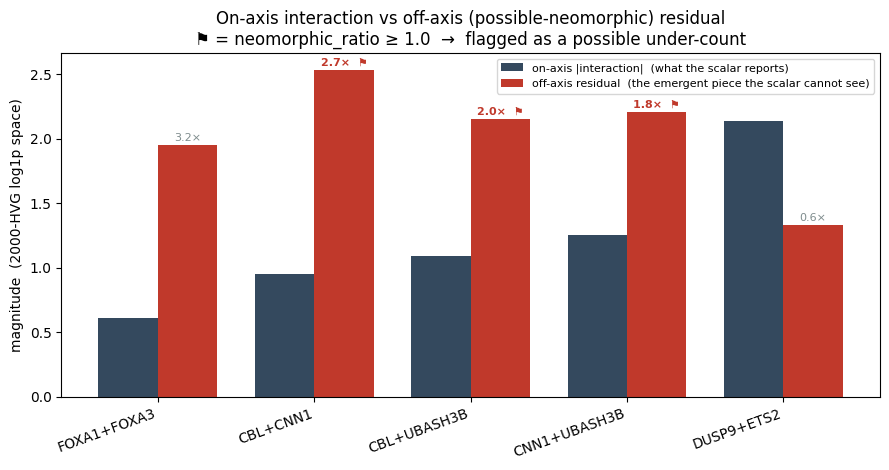

The three synergy pairs all carry off-axis ≥ on-axis (flagged as possible
neomorphic under-counts). DUSP9+ETS2 buffering is a clean ON-axis masking
(ratio < 1, NOT flagged) — exactly the pair that most sharply matches the paper.


In [4]:
# On-axis interaction (what the scalar reports) vs off-axis residual (what it can't see).
pairs = list(results)
on = np.array([abs(geoms[p].on_axis_interaction) for p in pairs])
off = np.array([geoms[p].off_axis_residual for p in pairs])
ratio = np.array([geoms[p].neomorphic_ratio for p in pairs])
flagged = np.array(['neomorphic' in results[p].reason for p in pairs])

srt = np.argsort(-ratio)  # largest neomorphic ratio first
pairs = [pairs[i] for i in srt]
on, off, ratio, flagged = on[srt], off[srt], ratio[srt], flagged[srt]

x = np.arange(len(pairs)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - w / 2, on, w, color='#34495e',
       label='on-axis |interaction|  (what the scalar reports)')
ax.bar(x + w / 2, off, w, color='#c0392b',
       label='off-axis residual  (the emergent piece the scalar cannot see)')
for i, (o, fl, rt) in enumerate(zip(off, flagged, ratio)):
    tag = f'{rt:.1f}×' + ('  ⚑' if fl else '')
    ax.annotate(tag, (i + w / 2, o), textcoords='offset points', xytext=(0, 3),
                ha='center', fontsize=8, fontweight='bold' if fl else 'normal',
                color='#c0392b' if fl else '#7f8c8d')
ax.set_xticks(x); ax.set_xticklabels(pairs, rotation=20, ha='right')
ax.set_ylabel('magnitude  (2000-HVG log1p space)')
ax.set_title('On-axis interaction vs off-axis (possible-neomorphic) residual\n'
             '⚑ = neomorphic_ratio ≥ 1.0  →  flagged as a possible under-count')
ax.legend(fontsize=8, loc='upper right')
fig.tight_layout(); plt.show()

print('The three synergy pairs all carry off-axis ≥ on-axis (flagged as possible')
print('neomorphic under-counts). DUSP9+ETS2 buffering is a clean ON-axis masking')
print('(ratio < 1, NOT flagged) — exactly the pair that most sharply matches the paper.')

## Part 1 — CBL+CNN1: a resolved **synergy** (the paper's flagship)

Norman 2019's flagship *unexpected* result: **CBL+CNN1** drives an **emergent erythroid
state** far beyond the additive sum (Fig 3; validated in HUDEP2 cells). NUDGE agrees — the
combo overshoots the additive prediction and the interaction CI sits clearly above 0. This is
one of the two pairs the paper characterises explicitly.

In [5]:
r = results['CBL+CNN1']; f = r.fit
print('CALL:', r.call.upper())
print(f'  effect(CBL)   = {f.effect_a:+.3f}')
print(f'  effect(CNN1)  = {f.effect_b:+.3f}')
print(f'  additive pred = {f.additive_pred:+.3f}')
print(f'  observed A+B  = {f.effect_ab:+.3f}')
print(f'  interaction   = {f.interaction:+.3f}  95% CI '
      f'[{f.ci_interaction[0]:+.3f}, {f.ci_interaction[1]:+.3f}]')
print('\n' + r.reason)

CALL: SYNERGISTIC
  effect(CBL)   = +1.481
  effect(CNN1)  = +1.856
  additive pred = +3.336
  observed A+B  = +4.285
  interaction   = +0.949  95% CI [+0.480, +1.423]

interaction +0.949 (95% CI [+0.48, +1.42]) is clearly > 0 and a free A+B level beats the additive null by ΔBIC=18.8 — SUPER-ADDITIVE / synergistic (log-fold-change space). NOT a hidden-node claim (NUDGE-LIM-009); presumes both single arms are correctly measured and an approximately-affine readout (NUDGE-LIM-006) | large off-axis residual (‖ = 2.54 ≈ 2.7× the on-axis interaction): the scalar may UNDER-count an emergent (possible-neomorphic) component — BUT an off-axis residual is EQUALLY consistent with a batch / ambient / technical artifact aligned with the A+B condition (NUDGE-LIM-009), is NOT by itself evidence of emergent biology, and must not be read as corroboration of the interaction


## Part 2 — DUSP9+ETS2: an honest **buffering** call

The paper reports the **DUSP9 phenotype dominates** and *antagonises* ETS2. NUDGE
sees exactly that: DUSP9's single-arm effect is large, and the combo lands **near
DUSP9-alone** — well *below* the additive prediction. The interaction CI is clearly
negative → sub-additive / epistatic buffering.

In [6]:
r = results['DUSP9+ETS2']; f = r.fit
print('CALL:', r.call.upper())
print(f'  effect(DUSP9) = {f.effect_a:+.3f}   effect(ETS2) = {f.effect_b:+.3f}')
print(f'  additive pred = {f.additive_pred:+.3f}   observed A+B = {f.effect_ab:+.3f}'
      f'   (≈ DUSP9 alone → DUSP9 is epistatic)')
print(f'  interaction   = {f.interaction:+.3f}  95% CI '
      f'[{f.ci_interaction[0]:+.3f}, {f.ci_interaction[1]:+.3f}]')
print('\n' + r.reason)

CALL: BUFFERING
  effect(DUSP9) = +4.791   effect(ETS2) = +1.660
  additive pred = +6.451   observed A+B = +4.311   (≈ DUSP9 alone → DUSP9 is epistatic)
  interaction   = -2.140  95% CI [-2.636, -1.598]

interaction -2.14 (95% CI [-2.64, -1.6]) is clearly < 0 and a free A+B level beats the additive null by ΔBIC=156.3 — SUB-ADDITIVE / buffering / epistatic (log-fold-change space). NOT a hidden-node claim (NUDGE-LIM-009); presumes both single arms are correctly measured and an approximately-affine readout (NUDGE-LIM-006)


## Part 3 — FOXA1+FOXA3: **additive** (paralogs on the null)

Two paralogous forkhead factors: their combination sits on the additive line — the
interaction CI straddles 0 and a free A+B level does **not** earn its parameter over
the additive null. NUDGE calls `additive` (not a false synergy).

In [7]:
r = results['FOXA1+FOXA3']; f = r.fit
print('CALL:', r.call.upper())
print(f'  additive pred = {f.additive_pred:+.3f}   observed A+B = {f.effect_ab:+.3f}')
print(f'  interaction   = {f.interaction:+.3f}  95% CI '
      f'[{f.ci_interaction[0]:+.3f}, {f.ci_interaction[1]:+.3f}]')
print('\n' + r.reason)

CALL: ADDITIVE
  additive pred = +5.035   observed A+B = +4.424
  interaction   = -0.611  95% CI [-1.367, +0.249]

interaction -0.611 (95% CI [-1.37, +0.249]) straddles 0 and a free A+B level does not beat the additive null by ΔBIC>2 (ΔBIC=-2.1) — the combo is the additive sum of A and B (log-fold-change space; same knob, more of it)


## What this is — and what it is **not** (the honesty rule)

An **independent literature fact-check** graded NUDGE's five calls against Norman 2019. The
honest score is **2/5 explicitly confirmed, 2/5 cluster-consistent-but-unlabeled, 1/5 a
paralog control the paper never analyses** — *not* a clean "matches the taxonomy on all five":

- ✅ **CBL+CNN1 → synergistic** and **DUSP9+ETS2 → buffering** are **explicit** matches to
  per-pair statements in Norman 2019 (Fig 3 emergent erythroid synergy; Fig 5 DUSP9-dominant
  suppression of ETS2). These two are the real validation.
- ⚠️ **CBL+UBASH3B** and **CNN1+UBASH3B → synergistic** fall in the paper's erythroid
  RTK-regulator cluster (Fig 2B) but have **no explicit per-pair GI score** — *consistent
  with*, not *validated against*, a published label (CNN1 isn't even in that RTK group).
- ❗ **FOXA1+FOXA3 → additive** is a **paralog control Norman does not analyse**; the additive
  expectation comes from paralogy (and independent re-analysis), not from Norman.

Two caveats a careful reader needs:

- **Sign convention.** NUDGE's "buffering" = a *negative* interaction (sub-additive). In the
  fitness-GI convention Norman inherits, "buffering" is a *positive* GI — the **same concept**
  (antagonism / sub-additivity), the **opposite numeric sign**. NUDGE did not invert the paper.
- **Null comparability.** NUDGE scores interactions with a **Bliss (log-additive) scalar** null;
  Norman uses a fitness map + full-transcriptome regression. Agreement is at interaction
  **type/direction**, *not* a reproduction of Norman's GI scores — and a purely *orthogonal*
  emergent state is invisible to a scalar-along-the-additive-axis (it can only under-count
  synergy). The honest claim: *agrees with Norman 2019 on the two explicitly-labeled pairs, and
  is consistent with the paper's clusters on the rest.*

The fail-safe bounds (`NUDGE-LIM-009`), stated with every call:

- **A combo inherits its weakest single arm.** If either single arm is underpowered or a dead
  guide, NUDGE returns `unresolved` / `no-effect` — never a synergy call.
- **The additive null is effect-space-dependent** (log-fold-change / Bliss); reported with
  every call.
- **The interaction is a scalar along the additive axis** — a super-additive residual is **not
  by itself a hidden-node claim**, and an orthogonal emergent state is not captured. NUDGE now
  **quantifies** that blind spot: the **off-axis residual** rides on every call
  (`EpistasisFit.off_axis_residual` / `.neomorphic_ratio`) and appends a *possible-neomorphic
  under-count* warning when it rivals the on-axis interaction (the figure above) — a flag, not
  a discovery.
- A depth/batch confound aligned with the A+B condition, or a nonlinear readout
  (`NUDGE-LIM-006`), can still fool it — which is why the classifier abstains on underpowered
  or wide-CI combos.